In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Louisville_Metro_KY_-_Library_Collection_Inventory_.csv')

In [4]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


In [5]:
#Checking dtypes and adjusting as needed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1422972 non-null  float64
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 139.1+ MB


In [6]:
df = df.astype({'ISBN':'object'})
df.dtypes

BibNum               int64
Title               object
Author              object
ISBN                object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
ReportDate          object
ObjectId             int64
dtype: object

In [7]:
df['ISBN'] = df['ISBN'].astype(str)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1657555 non-null  object 
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 139.1+ MB


In [9]:
#Dropping columns
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice', 'ReportDate',
       'ObjectId'],
      dtype='object')

In [10]:
df.drop(['ObjectId'], axis=1, inplace =True)


In [11]:
df['ReportDate'].unique()

array(['2022/07/01 04:00:00+00'], dtype=object)

In [12]:
df.drop(['ReportDate'], axis=1, inplace=True)

In [13]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice'],
      dtype='object')

In [14]:
#Missing data
df.isna()

df.isna().sum()

BibNum                  0
Title                   1
Author             195724
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        205
ItemLocation            0
ItemPrice               0
dtype: int64

In [15]:
df.loc[df['Title'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
243965,2239375,NaN,NaN,nan,0,Book,NaN,Crescent Hill,0.0


In [16]:
df = df.drop(243965)

In [17]:
df.isna().sum()

BibNum                  0
Title                   0
Author             195723
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        204
ItemLocation            0
ItemPrice               0
dtype: int64

In [18]:
df.loc[df['ItemCollection'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
8026,1353780,LANKIE MANTITA,LESLIE PATRICELLI,nan,0,Book,NaN,Shively,0.0
8587,2511351,My First Pet,NaN,nan,0,Book,NaN,Newburg,0.0
10501,1362079,Act of War,"Brown, Dale",nan,0,Book,NaN,Bon Air,0.0
16848,2410700,FOUR,VERONICA ROTH,nan,0,Book,NaN,Crescent Hill,0.0
22165,2481658,designing your work life,bill burnett,nan,0,Book,NaN,St Matthews,0.0
...,...,...,...,...,...,...,...,...,...
1656927,2528221,The Khipu and the Final Key,Dee Garretson,nan,0,Book,NaN,Northeast,0.0
1656933,2528222,MOMMY'S DISEASE,CAROLYN HANNAN,nan,0,Book,NaN,Southwest,0.0
1657038,2527377,use,NaN,nan,0,Book,NaN,Northeast,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


In [19]:
df.ItemCollection.unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [20]:
item_collection_na = df.ItemCollection.isna().sum()
total_rows = df.shape[0]
per_item_collection_na = (item_collection_na / total_rows) * 100
per_item_collection_na

np.float64(0.01230729134616429)

In [21]:
zero_pub_yr = df[df['PublicationYear'] == 0]
zero_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
5054,1348353,Stolen legacy: the Egyptian origins of western...,"James, George G. M",nan,0,Book,Interlibrary Loan,Main,0.00
6417,1351064,Bước vào đời : tuồng cải lương,NaN,nan,0,DVD,Adult DVD,Iroquois,29.99
6515,1351072,Đừng phụ tình đời : DVD cải lương,NaN,nan,0,Videorecording,Adult DVD,Iroquois,29.99
6592,1351079,Người đẹp và tỷ phú,NaN,nan,0,DVD,Adult DVD,South Central,29.99
6721,1351089,Đẹp từng centimet.,NaN,nan,0,DVD,Adult DVD,South Central,29.99
...,...,...,...,...,...,...,...,...,...
1657143,2528085,"Cognitive Mapping : Past, Present, and Future","Kitchin, Rob",nan,0,Book,Interlibrary Loan,Main,0.00
1657146,2528087,Eye of the Beholder,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657175,2528088,Sharp Edges,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.00


In [22]:
zero_item_price = df[df['ItemPrice'] == 0]
zero_item_price

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
99,2263735,The Cornwalls Vanish,"DuBois, Brendan",9780316489256.0,2019,Ebook,Electronic,Main,0.0
350,2263736,The Best Cook in the World,"Bragg, Rick",9780525520283.0,2018,Ebook,Electronic,Main,0.0
351,2263737,The Art of Tapestry Weaving,"Mezoff, Rebecca",9781635861365.0,2020,Ebook,Electronic,Main,0.0
352,2263738,Cornwall's Wonderland,"Quiller-couch, Mabel",nan,2021,Ebook,Electronic,Main,0.0
353,2263739,Target: Alex Cross,"Patterson, James",9780316417518.0,2018,Ebook,Electronic,Main,0.0
...,...,...,...,...,...,...,...,...,...
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.0
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657504,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


In [23]:
#Find duplicated data
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
duplicated_rows

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,19.99
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,19.99
5,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Remote Shelving - Main,19.99
6,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,13.00
7,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,13.00
...,...,...,...,...,...,...,...,...,...
1657500,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657501,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.00
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.00


Rows cannot be validated as duplicated data or as simply duplicate items.

In [24]:
#Find unique values for qualitative data
df['Title'].value_counts()

Title
The courier-journal                                           1352
The Blood-horse.                                              1028
People weekly.                                                 909
Annual report.                                                 588
Consumer reports.                                              498
                                                              ... 
Jeeves and the wedding bells : an homage to P.G. Wodehouse       1
Sandrine's Case                                                  1
Ghostgirl : lovesick                                             1
Daughters of the sea : Hannah                                    1
Abstract painting : the elements of visual language              1
Name: count, Length: 601965, dtype: int64

In [25]:
df['ItemCollection'].value_counts()

ItemCollection
Adult Non-Fiction         372781
Electronic                237469
Adult Fiction             173481
Children's Non-Fiction     86854
Mystery                    60164
                           ...  
Digital Camera                18
Listening Device              16
Launchpad                     10
Teen Reference                 9
Telescope                      6
Name: count, Length: 64, dtype: int64

In [37]:
df['ItemCollection'].unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

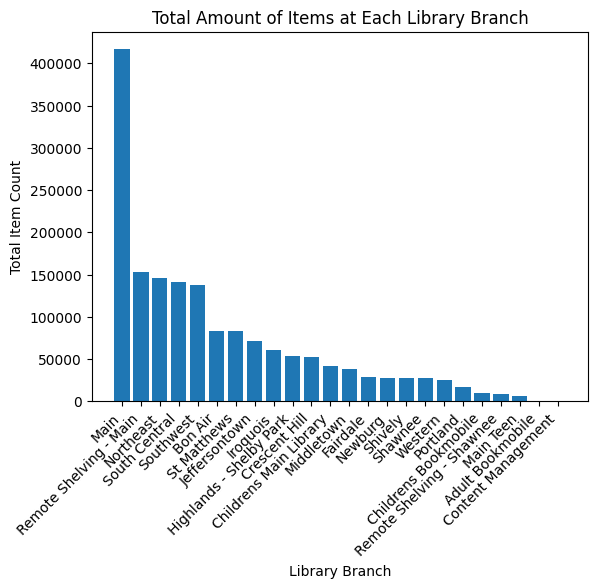

In [26]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

In [27]:
df.ItemType.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

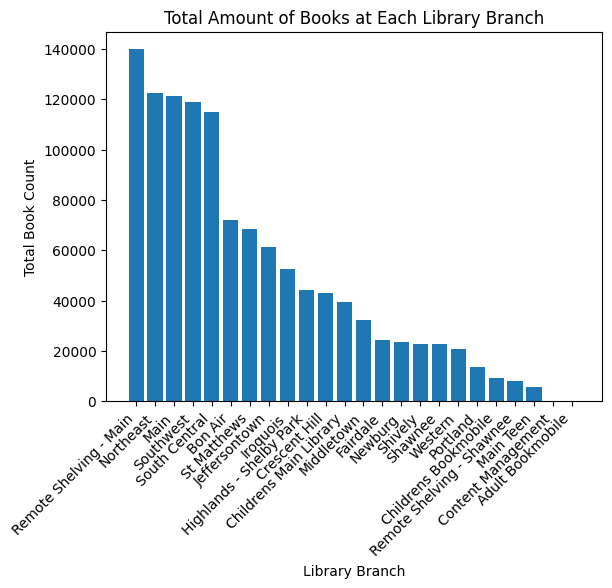

In [34]:
book_itemtype = df[df['ItemType'] == 'Book']
book_count = book_itemtype.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
book_count

plt.bar(book_count.index, book_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Book Count')
plt.title('Total Amount of Books at Each Library Branch')

plt.show()



In [ ]:
itemtype_by_loc = df.groupby('ItemLocation')['ItemType'].value_counts().sort_values(ascending=False)

In [ ]:
#Look over quantitative data
df['ItemPrice'].describe().apply(lambda x: f'${x:,.2f}')

count    $1,657,554.00
mean            $17.40
std             $20.12
min              $0.00
25%              $7.40
50%             $14.99
75%             $24.00
max          $1,077.00
Name: ItemPrice, dtype: object

In [ ]:
df['ItemPrice'] = df['ItemPrice'].apply(lambda x: f'${x:,.2f}')

In [ ]:
df[df['ItemPrice'] == 0.0]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice


In [ ]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9780071605878.0,2009,Book,Adult Non-Fiction,Main,$25.95
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9780071478939.0,2007,Book,ELL Collection,South Central,$20.00
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9780071496421.0,2008,Book,ELL Collection,South Central,$20.00
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99


In [ ]:
df['ISBN'][0]

'9780071605878.0'

In [ ]:
type(df['ISBN'][0])

str

In [ ]:
avg_itemprice_by_type = df.groupby('ItemType')['ItemPrice'].mean().round(2)
avg_itemprice_by_type

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
title_by_yr = df.groupby('PublicationYear')['Title'].value_counts()
title_by_yr

PublicationYear  Title                                                                      
0                Annual report.                                                                 495
                 Louisville.                                                                    455
                 Kentucky living.                                                               434
                 Industrial resources: Kentucky                                                 352
                 News and Tribune.                                                              343
                                                                                               ... 
2099             Miracles on the Hardwood                                                         1
2109             Murder knocks twice : a mystery                                                  4
5124             Annual report of the Louisville City Hospital.                                   6
9999   

In [ ]:
odd_pub_yr = df[df['PublicationYear'] > 2025]
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,30528
299609,407990,Residual life assessment of major light water ...,NaN,NaN,9999,Book,Government Documents,Main,75.00,2022/07/01 04:00:00+00,299610
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",NaN,9999,Book,Mystery,Main,14.95,2022/07/01 04:00:00+00,725314
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731137
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731138
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731139
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731140
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731141
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731142
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,756231


In [ ]:
df['PublicationYear'] = df['PublicationYear'].replace(2109, 2019)

In [ ]:
df.loc[1551094]

BibNum                                       2230396
Title              Love and death among the cheetahs
Author                                   Bowen, Rhys
ISBN                                 9780451492845.0
PublicationYear                                 2019
ItemType                                        Book
ItemCollection                               Mystery
ItemLocation                           Jeffersontown
ItemPrice                                      13.75
ReportDate                    2022/07/01 04:00:00+00
ObjectId                                     1551095
Name: 1551094, dtype: object

In [ ]:
odd_pub_yr = df[df['PublicationYear'] > 2025]
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,30528
299609,407990,Residual life assessment of major light water ...,NaN,NaN,9999,Book,Government Documents,Main,75.00,2022/07/01 04:00:00+00,299610
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",NaN,9999,Book,Mystery,Main,14.95,2022/07/01 04:00:00+00,725314
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731137
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731138
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731139
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731140
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731141
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731142
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,756231


In [ ]:
df.loc[725313, 'PublicationYear'] = 1928
df.loc[725313]

BibNum                                                   820258
Title              The Greene murder case : a Philo Vance story
Author                                          Van Dine, S. S.
ISBN                                                        NaN
PublicationYear                                            1928
ItemType                                                   Book
ItemCollection                                          Mystery
ItemLocation                                               Main
ItemPrice                                                 14.95
ReportDate                               2022/07/01 04:00:00+00
ObjectId                                                 725314
Name: 725313, dtype: object

In [ ]:
odd_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
30527,2344805,The Shift,"Johnson, Tory",9780316286626.0,2050,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,30528
299609,407990,Residual life assessment of major light water ...,NaN,NaN,9999,Book,Government Documents,Main,75.00,2022/07/01 04:00:00+00,299610
725313,820258,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",NaN,9999,Book,Mystery,Main,14.95,2022/07/01 04:00:00+00,725314
731136,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731137
731137,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731138
731138,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731139
731139,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731140
731140,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731141
731141,832136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",NaN,5124,Serial,Kentucky History,Main,2.00,2022/07/01 04:00:00+00,731142
756230,2289915,Everything Will Be Okay,"Perino, Dana",9781538708873.0,2099,Ebook,Electronic,Main,0.00,2022/07/01 04:00:00+00,756231


In [ ]:
yearly_avg_of_pub = df.groupby('Title')['PublicationYear'].sum()
yearly_avg_of_pub

Title
!!!" rain sounds "!!!                                                                                2021
!Tention                                                                                             2021
!Viva Cristo Rey! The Cristero Rebellion and the church-state conflict in Mexico                     1974
" --In pursuit of the American dream"                                                                1985
"... And a credit to his race;" the hard life and times of Joseph Louis Barrow, a.k.a. Joe Louis.    1974
                                                                                                     ... 
에스콰이어 코리아 (Esquire Korea)                                                                            2021
엘르 코리아 (ELLE Korea)                                                                                  6063
코스모폴리탄 코리아 (Cosmopolitan Korea)                                                                      6063
하퍼스바자 코리아 (Harper's BAZAAR Korea)       